In [227]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [228]:
import sys, pathlib

# adjust this to your repo root if different
repo_root = pathlib.Path.cwd()

repo_root = repo_root.parent.parent

sys.path.insert(0, str(repo_root))
print('Inserted repo root into sys.path:', repo_root)

Inserted repo root into sys.path: /Users/fabian/qecsim


In [229]:
from scipy.optimize import curve_fit, brentq
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.ticker import FuncFormatter
import glob
import re

In [230]:
# Shared across poth types
DISTANCES = [3, 5, 7, 9]
N_SAMPLES  = 20_000
LABEL      = "CircuitNoise"
MARKERS    = ['o', 'v', '*', 's']
P_TEST     = np.array([2e-3, 2.5e-3, 3e-3])

In [231]:
def load_ptms(
    base_dir: str,
    label: str,
    distances: list[int],
) -> tuple[dict, dict, dict]:
    """
    Returns (ideal, noisy, probs) dicts keyed by distance.
    """
    
    ideal, noisy, probs = {}, {}, {}
    for d in distances:
        ideal[d] = np.load(f"{base_dir}/ptm_ideal_d{d}_{label}.npy")
        p_list = sorted(
            float(re.search(r"_p([0-9eE+\-.]+)_", f).group(1))
            for f in glob.glob(f"{base_dir}/ptm_noisy_d{d}_p*_{label}.npy")
        )
        probs[d]  = np.array(p_list)
        noisy[d]  = [np.load(f"{base_dir}/ptm_noisy_d{d}_p{p:.2e}_{label}.npy") for p in probs[d]]
    return ideal, noisy, probs

In [232]:
def calculate_infidelity(ptm_ideal: np.ndarray, ptm_noisy: np.ndarray) -> float:
    ptm_ideal = ptm_ideal.copy()
    ptm_noisy = ptm_noisy.copy()
    ptm_ideal[0, 0] = 1
    ptm_noisy[0, 0] = 1
    # normalization dependent on type
    # -> 4 for memory, 16 for surgery
    d2 = ptm_ideal.shape[0]          
    return 1 - np.trace(ptm_ideal.T @ ptm_noisy) / d2

In [233]:
def calculate_infidelity_sigma(ptm_ideal: np.ndarray, N_samples: int) -> float:
    """
    1-sigma upper bound via error propagation through sample means.
    """
    
    d2 = ptm_ideal.shape[0]
    k  = 2 if d2 == 4 else 4
    w  = ptm_ideal.copy()
    w[0, 0] = 0.0
    return float(np.sqrt((1.0 / d2) ** 2 * np.sum(w ** 2) / (k * N_samples)))

In [234]:
# Define a function to model the infidelity as a polynomial in log(p)
def polynomial_logp(log_p, *coeffs):
    """Polynomial in log(p), coeffs = [c0, c1, c2, ...]"""
    return sum(c * log_p**k for k, c in enumerate(coeffs))

In [235]:
def fit_and_find_crossing(data_dict, sigmas = None, fit_distances=[7, 9], degree=4):
    """
    Fit infidelity curves for specified distances with a polynomial in log(p),
    then find the crossing point of the two fit distances.

    Parameters
    ----------
    data_dict : dict
        Dictionary with distances as keys and (p, infidelities) tuples as values
    sigmas : dict
        Dictionary with all gaussian error propagated error bars!
    fit_distances : list
        Distances to fit (default [7, 9])
    degree : int
        Polynomial degree

    Returns
    -------
    p_threshold : float
        Estimated threshold (crossing point)
    fit_funcs : dict
        Dictionary of fitted curve functions of p, keyed by distance
    """
    
    fit_funcs, coeffs_dict, covs_dict = {}, {}, {}
    
    for d in fit_distances:
        
        p_d, inf_d = data_dict[d]
        log_p = np.log(p_d)
        sigma_arr = np.full(len(inf_d), sigmas[d]) if sigmas is not None else None

        # Get curve fit with covariance mtx
        coeffs, pcov = curve_fit(
            polynomial_logp, log_p, inf_d,
            p0=np.ones(degree + 1),
            sigma=sigma_arr,
            absolute_sigma=(sigma_arr is not None),
        )
        coeffs_dict[d] = coeffs
        covs_dict[d]   = pcov

        def make_fit(coeff_vals):
            def fit_func(p):
                return polynomial_logp(np.log(p), *coeff_vals)
            return fit_func
        
        fit_funcs[d] = make_fit(coeffs)

    # Find crossing: solve fit_d1(p) - fit_d2(p) = 0
    d1, d2 = fit_distances
    fit_d1 = fit_funcs[d1]
    fit_d2 = fit_funcs[d2]
    
    def diff(p):
        return fit_d1(p) - fit_d2(p)

    # Search in the overlapping p range
    p_d1, _ = data_dict[d1]
    p_d2, _ = data_dict[d2]
    p_min = max(p_d1.min(), p_d2.min())
    p_max = min(p_d1.max(), p_d2.max())

    # Check that a sign change exists (i.e. curves actually cross)
    if diff(p_min) * diff(p_max) > 0:
        raise ValueError(
            f"No sign change found in [{p_min:.2e}, {p_max:.2e}]. "
            "Curves may not cross in this range — check your data or expand the p range."
        )

    p_threshold = brentq(diff, p_min, p_max)

    return p_threshold, fit_funcs, coeffs_dict, covs_dict


In [236]:
def compute_threshold_spread(
    data_dict, sigmas,
    degrees=(3, 4, 5),
    fit_distances=[7, 9],
):
    """
    Quantify uncertainty by repeating the threshold fit
    across polynomial degrees

    Returns
    -------
    results : dict  {degree: (p_th, inf_th, fit_funcs, coeffs, covs)}
        Failed degrees contain (nan, nan, None, None, None).
    sigma_sys_p   : float  — half-range of p*   across degrees
    sigma_sys_inf : float  — half-range of I(p*) across degrees
    """
    d1, d2 = fit_distances
    results = {}

    for deg in degrees:
        p_th, fit_funcs, coeffs, covs = fit_and_find_crossing(
            data_dict, sigmas=sigmas,
            degree=deg, fit_distances=fit_distances,
        )
        inf_th = (fit_funcs[d1](p_th) + fit_funcs[d2](p_th)) / 2
        results[deg] = (p_th, inf_th, fit_funcs, coeffs, covs)

    valid = [(v[0], v[1]) for v in results.values() if not np.isnan(v[0])]

    p_vals   = [v[0] for v in valid]
    inf_vals = [v[1] for v in valid]

    sigma_sys_p   = (max(p_vals)   - min(p_vals))   / 2
    sigma_sys_inf = (max(inf_vals) - min(inf_vals)) / 2

    return results, sigma_sys_p, sigma_sys_inf

In [237]:
def print_infidelity_results(
    label, results, sigma_sys_p, sigma_sys_inf, sigma_stat_I,
    p_values, primary_degree=4, fit_distances=[7, 9],
):
    """
    Print threshold summary.

    Parameters
    ----------
    results       : dict from compute_threshold_spread
    sigma_sys_p   : systematic uncertainty on p* (degree spread)
    sigma_sys_inf : systematic uncertainty on I(p*) (degree spread)
    sigma_stat_I  : Gaussian per-point infidelity error (data only)
    """
    d1, d2 = fit_distances
    p_th, inf_th, fit_funcs, _, _ = results[primary_degree]

    print(f"\n{'='*58}")
    print(f"  {label}".center(58))
    print(f"{'='*58}")
    print(f"  p_th    = {p_th:.4e}  ±{sigma_sys_p:.2e}  (sys, degree spread)")
    print(f"  I(p_th) = {inf_th:.4f}   ±{sigma_sys_inf:.4f}  (sys, degree spread)")
    print(f"  σ_I     = {sigma_stat_I:.2e}  (Gaussian per data point)")
    print()
    print(f"  {'deg':>4} | {'p*':>12} | {'I(p*)':>8}")
    print(f"  {'─'*34}")
    for deg, (p, inf, _, _, _) in results.items():
        if not np.isnan(p):
            print(f"  {deg:>4} | {p:>12.6e} | {inf:>8.4f}")
        else:
            print(f"  {deg:>4} | {'failed':>12} | {'─':>8}")
    print()
    print(f"  Infidelity at test points (degree {primary_degree}):")
    print(f"  {'p':>8} | {'d='+str(d1):>14} | {'d='+str(d2):>14}")
    print(f"  {'─'*46}")
    valid_degrees = [deg for deg, v in results.items() if v[2] is not None]
    for p in p_values:
        inf_d1_vals = [results[deg][2][d1](p) for deg in valid_degrees]
        inf_d2_vals = [results[deg][2][d2](p) for deg in valid_degrees]
        spread_d1 = (max(inf_d1_vals) - min(inf_d1_vals)) / 2
        spread_d2 = (max(inf_d2_vals) - min(inf_d2_vals)) / 2
        print(
            f"  {p:.2e} | "
            f"{fit_funcs[d1](p):>6.4f} ±{spread_d1:.4f} | "
            f"{fit_funcs[d2](p):>6.4f} ±{spread_d2:.4f}"
        )

In [238]:
def sci_format(x, pos):
    return f"${x / 1e-3:g} \\times 10^{{-3}}$"

In [239]:
def plot_infidelity(
    probs, infidelities, sigmas,
    fit_funcs, p_threshold,
    p_low_cutoff, p_high_cutoff,
    *,
    title,
    xlim,
    ylim=None,
    legend_loc='lower right',
    inset_bounds=(0.15, 0.55, 0.35, 0.4),
    inset_xlim=None,
    inset_ylim=None,
    inset_xticks=None,
    inset_xformatter=None,
    sigma_thresh=None,           # placeholder for threshold band — added later
    fit_distances=(7, 9),
):
    d1, d2  = fit_distances
    dists   = sorted(probs.keys())
    c       = {d: f'C{i}' for i, d in enumerate(dists)}  # consistent colour map

    fig, ax = plt.subplots(figsize=(8, 6), dpi=150)

    # --- data points ---
    for i, d in enumerate(dists):
        ax.errorbar(
            probs[d], infidelities[d],
            yerr=sigmas[d],
            marker=MARKERS[i],
            linestyle='None',
            markersize=5,
            capsize=3,
            elinewidth=0.8,
            color=c[d],
            label=f'd={d}',
        )

    # --- fit curves (fitted region only) ---
    p_plot = np.geomspace(p_low_cutoff, p_high_cutoff, 300)
    ax.plot(p_plot, fit_funcs[d1](p_plot), '--', color=c[d1], linewidth=1.5, alpha=0.9, label=f'd={d1} fit')
    ax.plot(p_plot, fit_funcs[d2](p_plot), '--', color=c[d2], linewidth=1.5, alpha=0.9, label=f'd={d2} fit')

    # --- threshold ---
    ax.axvline(p_threshold, color='gray', linestyle='--', linewidth=1.5)
    if sigma_thresh is not None:
        ax.axvspan(
            p_threshold - sigma_thresh,
            p_threshold + sigma_thresh,
            alpha=0.15, color='gray', label=r'threshold $\pm 1\sigma$',
        )

    # --- axis formatting ---
    ax.set_xscale('log')
    ax.set_xlabel('Physical Error Rate $p$', fontsize=12)
    ax.set_ylabel('Infidelity', fontsize=12)
    ax.set_title(title, fontsize=16, weight='bold')
    ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)
    ax.legend(title='Distance', loc=legend_loc, framealpha=1.0)
    ax.grid(which='major', linestyle='-', linewidth=0.8, color='#d3d3d3')
    ax.grid(which='minor', linestyle=':', linewidth=0.8, color='#ebebeb')

    # --- inset ---
    if inset_xlim is not None:
        axins = ax.inset_axes(inset_bounds)

        for i, d in enumerate(dists):
            axins.errorbar(
                probs[d], infidelities[d],
                yerr=sigmas[d],
                marker=MARKERS[i],
                linestyle='None',
                markersize=4,
                capsize=3,
                elinewidth=0.8,
                color=c[d],
            )

        p_ins = np.geomspace(p_low_cutoff, p_high_cutoff, 300)
        axins.plot(p_ins, fit_funcs[d1](p_ins), '--', color=c[d1], linewidth=1.5, alpha=0.9)
        axins.plot(p_ins, fit_funcs[d2](p_ins), '--', color=c[d2], linewidth=1.5, alpha=0.9)
        axins.axvline(p_threshold, color='gray', linestyle='--', linewidth=1.5)

        axins.set_xscale('log')
        axins.set_xlim(inset_xlim)
        if inset_ylim is not None:
            axins.set_ylim(inset_ylim)
        if inset_xticks is not None:
            axins.set_xticks(inset_xticks)
        if inset_xformatter is not None:
            axins.xaxis.set_major_formatter(inset_xformatter)
            axins.xaxis.set_minor_formatter(plt.NullFormatter())
            axins.tick_params(axis='x', rotation=0, labelsize=10)
        else:
            axins.tick_params(axis='x', rotation=45, labelsize=8)
        axins.grid(which='major', linestyle='-', linewidth=0.8, color='#d3d3d3')
        axins.grid(which='minor', linestyle=':', linewidth=0.8, color='#ebebeb')

        ax.indicate_inset_zoom(axins, edgecolor='black', linewidth=1.5)

    plt.tight_layout()
    plt.show()

In [240]:
# Memory load PTMs, compute infidelities and finally error by gaussian error propagation!
ideal_m, noisy_m, probs_m = load_ptms("../data/ptm_matrices_memory", LABEL, DISTANCES)

infidelities_m = {
    d: [calculate_infidelity(ideal_m[d], ptm) for ptm in noisy_m[d]]
    for d in DISTANCES
}
sigmas_m = {d: calculate_infidelity_sigma(ideal_m[d], N_SAMPLES) for d in DISTANCES}

# Create cutoff since data in ultra low p and ultra high p regime destroy sign change for fit
# Here constant which results in oscilations
p_low_cutoff_m = 1.7e-3
p_high_cutoff_m = 5e-3

# Create data dictionary with all distances
data_memory = {
    d: (
        probs_m[d][mask := (probs_m[d] >= p_low_cutoff_m) & (probs_m[d] <= p_high_cutoff_m)],
        np.array(infidelities_m[d])[mask],
    )
    for d in DISTANCES
}

In [241]:
# Perform Fit
results_m, sigma_sys_p_m, sigma_sys_inf_m = compute_threshold_spread(data_memory, sigmas_m)
p_threshold_m = results_m[4][0]
fit_funcs_m   = results_m[4][2]


                           Memory                         
  p_th    = 4.0275e-03  ±1.78e-05  (sys, degree spread)
  I(p_th) = 0.0781   ±0.0009  (sys, degree spread)
  σ_I     = 2.17e-03  (Gaussian per data point)

   deg |           p* |    I(p*)
  ──────────────────────────────────
     3 | 3.991980e-03 |   0.0762
     4 | 4.027497e-03 |   0.0781
     5 | 4.027394e-03 |   0.0781

  Infidelity at test points (degree 4):
         p |            d=7 |            d=9
  ──────────────────────────────────────────────
  2.00e-03 | 0.0060 ±0.0004 | 0.0028 ±0.0008
  2.50e-03 | 0.0141 ±0.0000 | 0.0087 ±0.0001
  3.00e-03 | 0.0280 ±0.0003 | 0.0210 ±0.0006


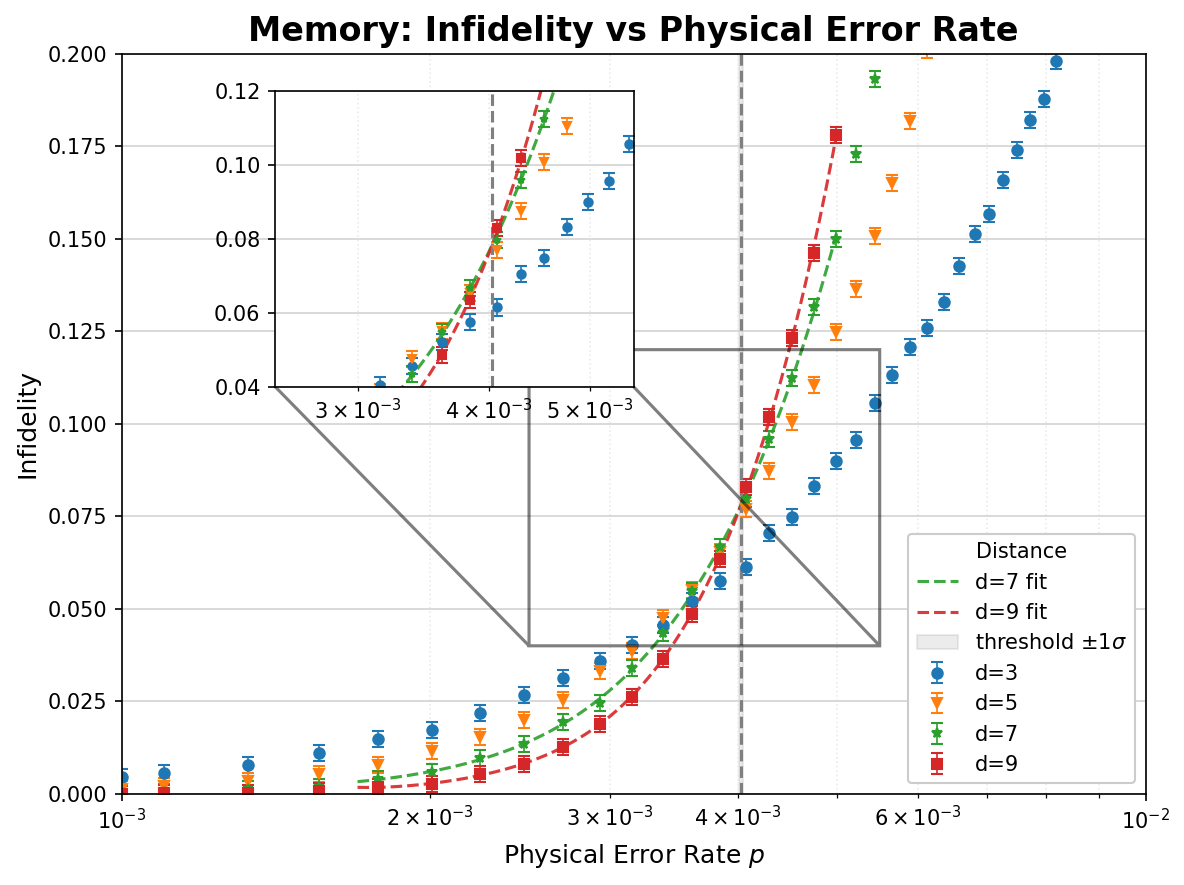


Approx. surgery infidelity at memory threshold: 0.7046


In [242]:
print_infidelity_results(
    'Memory', results_m, sigma_sys_p_m, sigma_sys_inf_m, sigmas_m[7], P_TEST
)
plot_infidelity(
    probs_m, infidelities_m, sigmas_m, fit_funcs_m, p_threshold_m,
    p_low_cutoff_m, p_high_cutoff_m,
    title='Memory: Infidelity vs Physical Error Rate',
    xlim=(1e-3, 1e-2),
    ylim=(0, 0.2),
    legend_loc='lower right',
    inset_bounds=(0.15, 0.55, 0.35, 0.4),
    inset_xlim=(2.5e-3, 5.5e-3),
    inset_ylim=(0.04, 0.12),
    sigma_thresh=sigma_sys_p_m,
)
# Surgery approximation
inf_th_m = (fit_funcs_m[7](p_threshold_m) + fit_funcs_m[9](p_threshold_m)) / 2
print(f"\nApprox. surgery infidelity at memory threshold: {1 - (1 - inf_th_m)**15:.4f}")

In [243]:
# Surgery load PTMs, compute infidelities and finally error by gaussian error propagation!
ideal_s, noisy_s, probs_s = load_ptms("../data/ptm_matrices_surgery", LABEL, DISTANCES)

infidelities_s = {
    d: [calculate_infidelity(ideal_s[d], ptm) for ptm in noisy_s[d]]
    for d in DISTANCES
}
sigmas_s = {d: calculate_infidelity_sigma(ideal_s[d], N_SAMPLES) for d in DISTANCES}

In [244]:
# Create cutoff since data in ultra low p and ultra high p regime destroy sign change for fit
# Here constant which results in oscilations
p_low_cutoff_s = 1.5e-3
p_high_cutoff_s = 3.5e-3

# Create data dictionary with all distances
data_surgery = {
    d: (
        probs_s[d][mask := (probs_s[d] >= p_low_cutoff_s) & (probs_s[d] <= p_high_cutoff_s)],
        np.array(infidelities_s[d])[mask],
    )
    for d in DISTANCES
}

In [245]:
# Run the fitting and crossing analysis (only fit d=7 and d=9)
results_s, sigma_sys_p_s, sigma_sys_inf_s = compute_threshold_spread(data_surgery, sigmas_s)
p_threshold_s = results_s[4][0]
fit_funcs_s   = results_s[4][2]


                          Surgery                         
  p_th    = 2.7819e-03  ±1.32e-05  (sys, degree spread)
  I(p_th) = 0.7541   ±0.0038  (sys, degree spread)
  σ_I     = 8.56e-04  (Gaussian per data point)

   deg |           p* |    I(p*)
  ──────────────────────────────────
     3 | 2.791255e-03 |   0.7571
     4 | 2.781861e-03 |   0.7541
     5 | 2.764779e-03 |   0.7495

  Infidelity at test points (degree 4):
         p |            d=7 |            d=9
  ──────────────────────────────────────────────
  2.00e-03 | 0.4035 ±0.0008 | 0.3240 ±0.0020
  2.50e-03 | 0.6496 ±0.0005 | 0.6217 ±0.0013
  3.00e-03 | 0.8145 ±0.0004 | 0.8289 ±0.0009


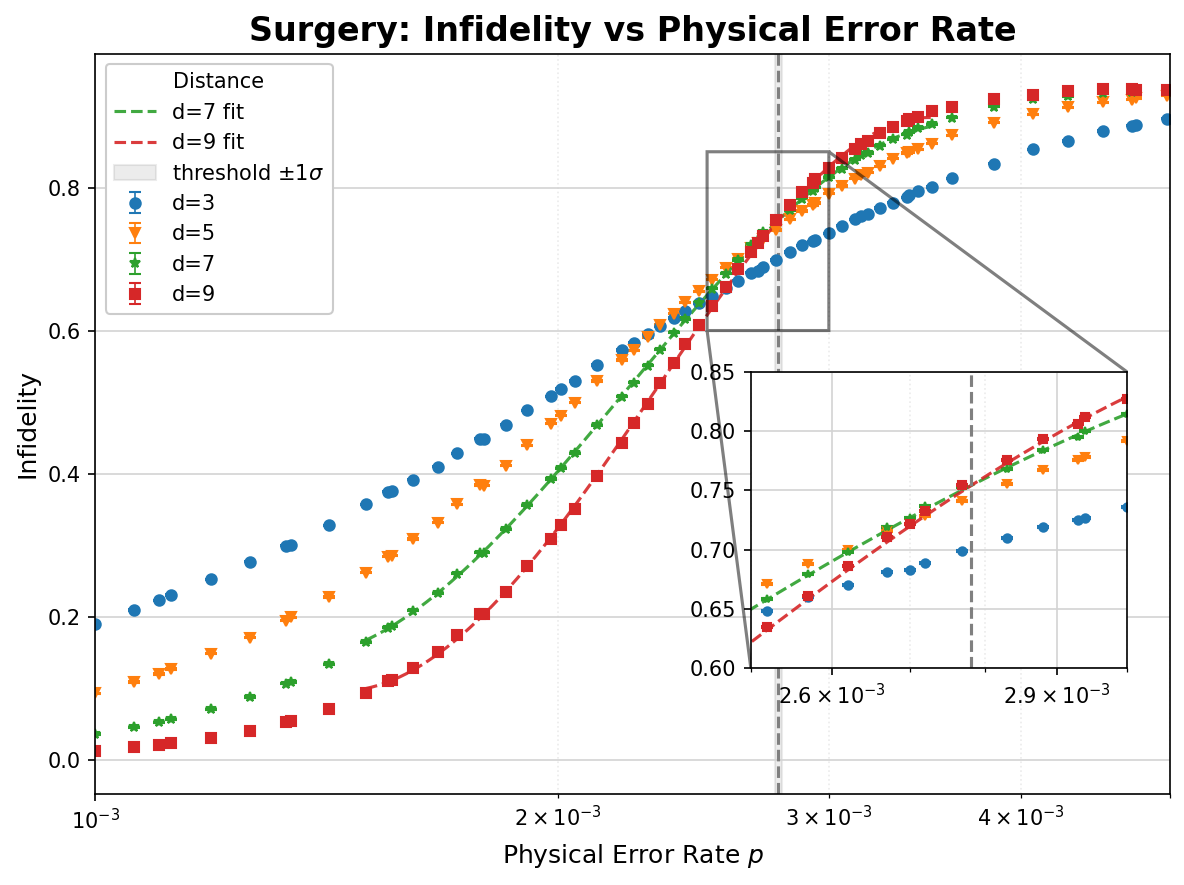

In [246]:
print_infidelity_results(
    'Surgery', results_s, sigma_sys_p_s, sigma_sys_inf_s, sigmas_s[7], P_TEST
)
plot_infidelity(
    probs_s, infidelities_s, sigmas_s, fit_funcs_s, p_threshold_s,
    p_low_cutoff_s, p_high_cutoff_s,
    title='Surgery: Infidelity vs Physical Error Rate',
    xlim=(1e-3, 5e-3),
    legend_loc='upper left',
    inset_bounds=(0.61, 0.17, 0.35, 0.4),
    inset_xlim=(2.5e-3, 3.0e-3),
    inset_ylim=(0.6, 0.85),
    inset_xticks=[2.6e-3, 2.9e-3],
    inset_xformatter=FuncFormatter(sci_format),
    sigma_thresh=sigma_sys_p_s,
)